In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df  = pd.read_excel(r'C:\Users\ACER\Desktop\task.xlsx')
df

,ID,Məhəllə,Otaq Sayı,Qiymət (AZN)
0,1,Yasamal,2,120000
1,2,Yasamal,2,115000
2,3,Nərimanov,3,145000
3,4,Xətai,2,125000
4,5,Yasamal,2,118000
5,6,Mərkəz,5,850000
6,7,Xətai,2,122000
7,8,Nərimanov,3,140000
8,9,Yasamal,1,55000
9,10,Gənclik,2,130000


In [4]:
# 1. Bizə lazım olan sütunu seçək (Rahatlıq üçün)
col = df['Qiymət (AZN)']

# 2. Lazımi Statistikaları Hesablayaq
mean_val = col.mean()          # Ədədi Orta
median_val = col.median()      # Median (Q2)
q1 = col.quantile(0.25)        # Q1 (25%)
q3 = col.quantile(0.75)        # Q3 (75%)
iqr = q3 - q1                  # IQR (Qutu genişliyi)

# 3. Outlier Sərhədlərini Təyin edək (Qızıl Qayda)
lower_bound = q1 - 1.5 * iqr   # Aşağı sərhəd
upper_bound = q3 + 1.5 * iqr   # Yuxarı sərhəd

# 4. Outlier-ləri (Sərhədi aşanları) tapaq
# Şərt: Aşağı sərhəddən kiçik VƏ YA (|) Yuxarı sərhəddən böyük
outliers = df[(col < lower_bound) | (col > upper_bound)]

print(median_val)
print(median_val)
print(q1)
print(q3)
print(iqr)
print(lower_bound)
print(upper_bound)
print(outliers)

126000.0
126000.0
119500.0
139000.0
19500.0
90250.0
168250.0
   ID  Məhəllə  Otaq Sayı  Qiymət (AZN)
5   6   Mərkəz          5        850000
8   9  Yasamal          1         55000


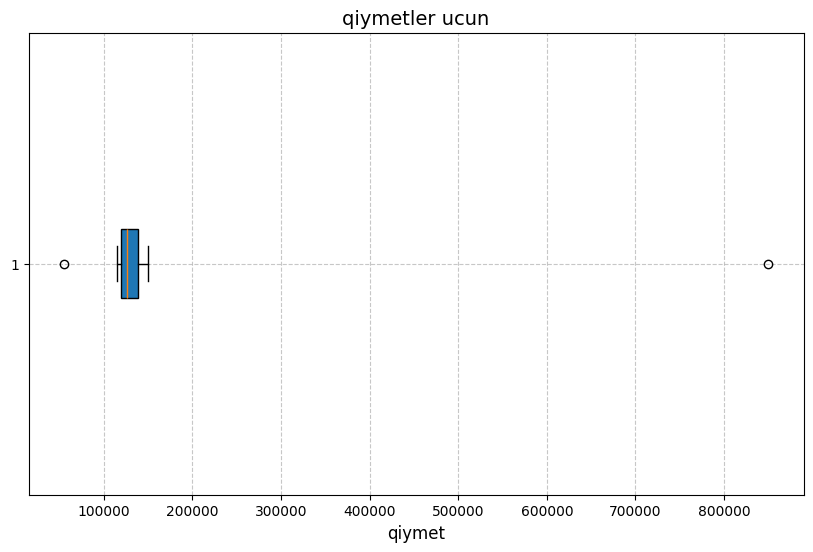

In [7]:

# 1. Şəklin ölçüsünü təyin edirik (Eni 10, Hündürlüyü 6)
plt.figure(figsize=(10, 6))

# 2. Boxplot-u qururuq
# df['Maas'] -> Sizin datanızdakı maaş sütunu
# vert=False -> Qrafiki üfüqi (yatıq) edir (baxmaq daha rahatdır)
# patch_artist=True -> Qutunun içini rəngləyir
plt.boxplot(col, vert=False, patch_artist=True)

# 3. Başlıq və Etiketlər (Qrafik anlaşıqlı olsun deyə)
plt.title('qiymetler ucun', fontsize=14)
plt.xlabel('qiymet', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7) # Arxa fona tor (setka) əlavə edirik

# 4. Şəkli göstəririk
plt.show()

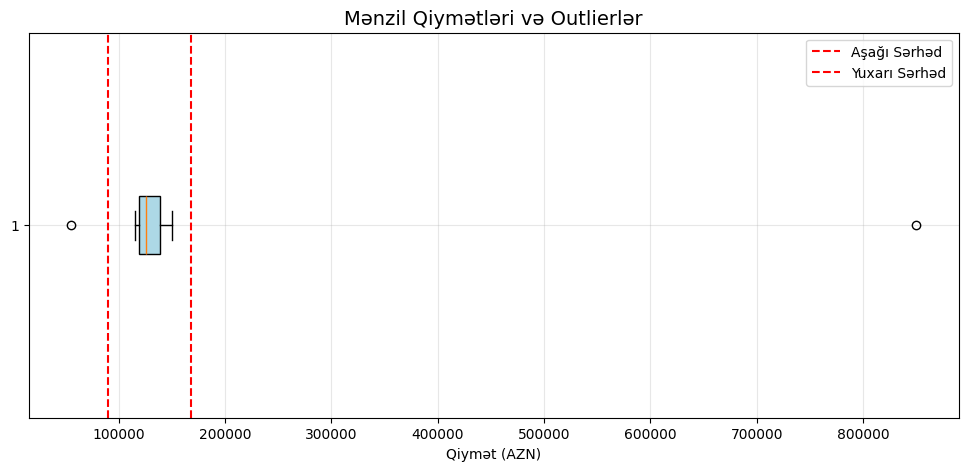

In [5]:
# --- 5. VİZUALİZASİYA (BOXPLOT) ---
plt.figure(figsize=(12, 5))

# Boxplot-u quraq
# vert=False (Üfüqi), patch_artist=True (Rəngli olsun)
plt.boxplot(col, vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))

# Üstünə Sərhəd Xətlərini də çəkək ki, tələbələr görsün
plt.axvline(x=lower_bound, color='red', linestyle='--', label='Aşağı Sərhəd')
plt.axvline(x=upper_bound, color='red', linestyle='--', label='Yuxarı Sərhəd')

plt.title('Mənzil Qiymətləri və Outlierlər', fontsize=14)
plt.xlabel('Qiymət (AZN)')
plt.legend() # Sərhəd xətlərinin adını göstər
plt.grid(True, alpha=0.3)

plt.show()